# Machine Learning Assignment 2
## Applying ML Algorithms

### Customer Personality Analysis

---

## 1. Data Preprocessing

### Loading & Inspection

Load the data, display first 5 rows, check for missing values.

In [313]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [314]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
print('Shape:', df.shape)
df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [315]:
missing = df.isnull().sum()
missing[missing > 0]

Income    24
dtype: int64

### Handle Missing Values

Median imputation for Income.

In [316]:

df['Income'].fillna(df['Income'].median(), inplace=True)
print( df['Income'].isnull().sum())

0


### Feature Engineering

- Create `Age` from `Year_Birth`
- Create `TotalSpending` by summing product columns
- Create `TotalChildren` by summing `Kidhome` and `Teenhome`

In [317]:
current_year = 2026
df['Age'] = current_year - df['Year_Birth']
df[['Year_Birth', 'Age']].head()

,Year_Birth,Age
0,1957,69
1,1954,72
2,1965,61
3,1984,42
4,1981,45


In [318]:
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpending'] = df[spending_cols].sum(axis=1)
df[['TotalSpending']].head()

,TotalSpending
0,1617
1,27
2,776
3,53
4,422


In [319]:
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
df[['Kidhome', 'Teenhome', 'TotalChildren']].head()

,Kidhome,Teenhome,TotalChildren
0,0,0,0
1,1,1,2
2,0,0,0
3,1,0,1
4,1,0,1


### Filtering

Remove unrealistic ages (<18 or >100) and zero-income rows.

In [320]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

df = df[df['Income'] > 0]
df.shape

(2237, 32)

### Encoding

- Label encode `Education` (Basic=0, Graduation=1, Master=2, PhD=3)
- One-hot encode `Marital_Status` (keep top 4 categories, group others as 'Other')

In [321]:
education_map = {
    'Basic': 0,
    'Graduation': 1,
    '2n Cycle': 1,
    'Master': 2,
    'PhD': 3
}
df['Education_Encoded'] = df['Education'].map(education_map)
print(df['Education'].value_counts())
print(df['Education_Encoded'].value_counts())

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64
Education_Encoded
1    1328
3     485
2     370
0      54
Name: count, dtype: int64


In [322]:

top4 = df['Marital_Status'].value_counts().head(4).index.tolist()


df["Marital_Status_Grouped"] = [
    val if val in top4 else "Other" for val in df["Marital_Status"]
]
dummies = pd.get_dummies(df['Marital_Status_Grouped'], prefix='Marital')
df = pd.concat([df, dummies], axis=1)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Age,TotalSpending,TotalChildren,Education_Encoded,Marital_Status_Grouped,Marital_Divorced,Marital_Married,Marital_Other,Marital_Single,Marital_Together
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,69,1617,0,1,Single,False,False,False,True,False
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,72,27,2,1,Single,False,False,False,True,False
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,61,776,0,1,Together,False,False,False,False,True
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,42,53,1,1,Together,False,False,False,False,True
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,45,422,1,3,Married,False,True,False,False,False


## 2. Supervised Learning - Regression

Target Variable: `TotalSpending` (continuous)

### Train/Test Split and Feature Scaling

In [323]:
cols_to_drop = ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Dt_Customer',
                'Marital_Status_Grouped', 'Z_CostContact', 'Z_Revenue',
                'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                'MntSweetProducts', 'MntGoldProds',
                'Kidhome', 'Teenhome']
df2 = df.drop(columns=cols_to_drop)
X = df2.drop(columns=['TotalSpending'])
y = df2['TotalSpending']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (1789, 22) Test: (448, 22)


In [324]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Linear Regression

In [325]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print('Linear Regression:')
print('MSE: ', round(mse_lr, 2))
print('RMSE:', round(rmse_lr, 2))
print('R^2: ', round(r2_lr, 4))

Linear Regression:
MSE:  70349.93
RMSE: 265.24
R^2:  0.8148


### Ridge Regression (alpha=1.0)

In [326]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print('Ridge Regression:')
print('MSE: ', round(mse_ridge, 2))
print('RMSE:', round(rmse_ridge, 2))
print('R^2: ', round(r2_ridge, 4))

Ridge Regression:
MSE:  70341.16
RMSE: 265.22
R^2:  0.8148


### Decision Tree Regressor (max_depth=5)

Decision Trees do not require scaling, but we use original features for consistency.

In [327]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print('Decision Tree Regressor:')
print('MSE: ', round(mse_dt, 2))
print('RMSE:', round(rmse_dt, 2))
print('R^2: ', round(r2_dt, 4))

Decision Tree Regressor:
MSE:  59744.72
RMSE: 244.43
R^2:  0.8427


### Regression Model Comparison

In [328]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Decision Tree Regressor'],
    'MSE': [mse_lr, mse_ridge, mse_dt],
    'RMSE': [rmse_lr, rmse_ridge, rmse_dt],
    'R^2 Score': [r2_lr, r2_ridge, r2_dt]
}).round(4)
print(comparison.to_string())

                     Model         MSE      RMSE  R^2 Score
0        Linear Regression  70349.9309  265.2356     0.8148
1         Ridge Regression  70341.1594  265.2191     0.8148
2  Decision Tree Regressor  59744.7159  244.4273     0.8427


## 3. Supervised Learning - Classification

Target Variable: `Response` (1 if customer accepted the last campaign, else 0)

### Class Distribution

In [329]:

print(df['Response'].value_counts())


Response
0    1903
1     334
Name: count, dtype: int64


### Train/Test Split and Feature Scaling

In [330]:
X = df2.drop(columns=['Response'])
y = df2['Response']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train_clf.shape, 'Test:', X_test_clf.shape)

Train: (1789, 22) Test: (448, 22)


In [331]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

### Logistic Regression (class_weight='balanced')

Classification Report:


              precision    recall  f1-score   support

           0       0.95      0.79      0.86       376
           1       0.42      0.78      0.54        72

    accuracy                           0.79       448
   macro avg       0.68      0.79      0.70       448
weighted avg       0.86      0.79      0.81       448



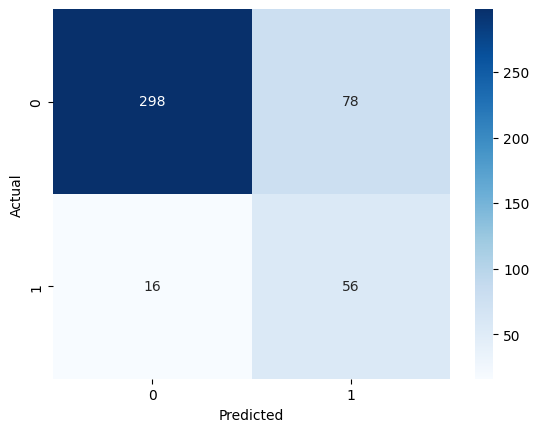

In [ ]:
logreg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logreg.fit(X_train_clf_scaled, y_train_clf)
y_pred_logreg = logreg.predict(X_test_clf_scaled)

print('Classification Report:')
print(classification_report(y_test_clf, y_pred_logreg))

cm_logreg = confusion_matrix(y_test_clf, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### K-Nearest Neighbors (n_neighbors=5)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       376
           1       0.74      0.36      0.49        72

    accuracy                           0.88       448
   macro avg       0.82      0.67      0.71       448
weighted avg       0.87      0.88      0.86       448



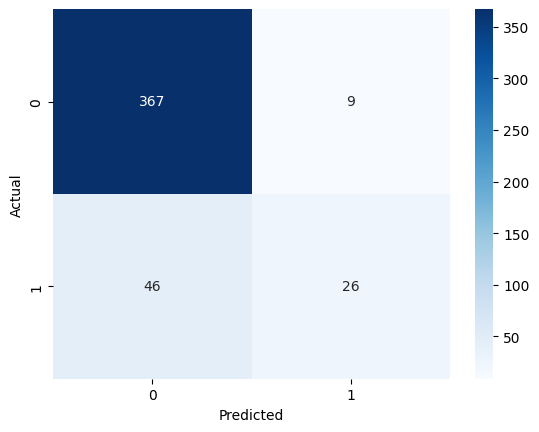

In [333]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_clf_scaled, y_train_clf)
y_pred_knn = knn.predict(X_test_clf_scaled)

print('Classification Report:')
print(classification_report(y_test_clf, y_pred_knn))

cm_knn = confusion_matrix(y_test_clf, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Random Forest Classifier (n_estimators=100)

Note: Random Forest does not require feature scaling.

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       376
           1       0.77      0.46      0.57        72

    accuracy                           0.89       448
   macro avg       0.84      0.72      0.76       448
weighted avg       0.88      0.89      0.88       448



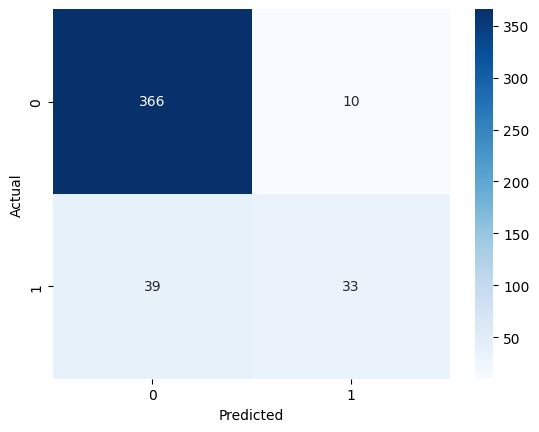

In [334]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_clf, y_train_clf)
y_pred_rf = rf.predict(X_test_clf)

print('Classification Report:')
print(classification_report(y_test_clf, y_pred_rf))

cm_rf = confusion_matrix(y_test_clf, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Classification Model Comparison

**Which metric is most important here?**

Since the classes are imbalanced (~15% positive), accuracy alone is misleading. **Recall** is the most important metric because we want to identify as many customers who would actually respond (minimize false negatives). F1-Score provides a good balance between precision and recall.

In [335]:

print("Logistic Regression")
print("  Accuracy: ", round(accuracy_score(y_test_clf, y_pred_logreg), 4))
print("  Precision:", round(precision_score(y_test_clf, y_pred_logreg), 4))
print("  Recall:   ", round(recall_score(y_test_clf, y_pred_logreg), 4))
print("  F1-Score: ", round(f1_score(y_test_clf, y_pred_logreg), 4))
print()

print("K-Nearest Neighbors")
print("  Accuracy: ", round(accuracy_score(y_test_clf, y_pred_knn), 4))
print("  Precision:", round(precision_score(y_test_clf, y_pred_knn), 4))
print("  Recall:   ", round(recall_score(y_test_clf, y_pred_knn), 4))
print("  F1-Score: ", round(f1_score(y_test_clf, y_pred_knn), 4))
print()

print("Random Forest")
print("  Accuracy: ", round(accuracy_score(y_test_clf, y_pred_rf), 4))
print("  Precision:", round(precision_score(y_test_clf, y_pred_rf), 4))
print("  Recall:   ", round(recall_score(y_test_clf, y_pred_rf), 4))
print("  F1-Score: ", round(f1_score(y_test_clf, y_pred_rf), 4))


Logistic Regression
  Accuracy:  0.7902
  Precision: 0.4179
  Recall:    0.7778
  F1-Score:  0.5437

K-Nearest Neighbors
  Accuracy:  0.8772
  Precision: 0.7429
  Recall:    0.3611
  F1-Score:  0.486

Random Forest
  Accuracy:  0.8906
  Precision: 0.7674
  Recall:    0.4583
  F1-Score:  0.5739


## 4. Unsupervised Learning - Clustering

Goal: Segment customers using `TotalSpending`, `Income`, `Age`, and `TotalChildren`.

### Data Preparation

In [336]:
cluster_features = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

### Elbow Method

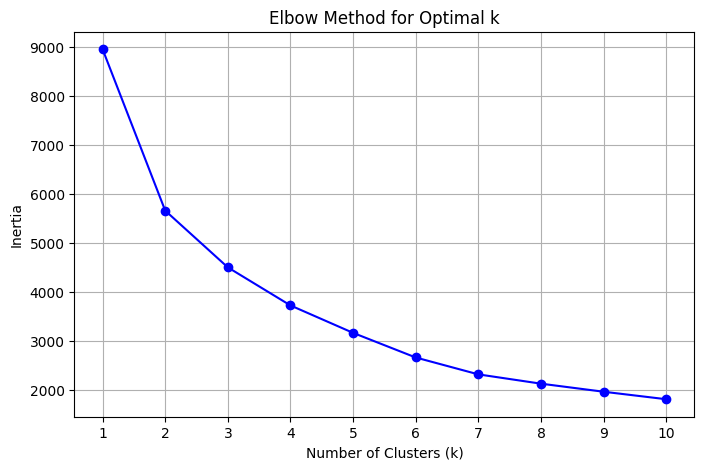

In [337]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### K-Means Clustering with Chosen k

Based on the elbow curve, we select the optimal number of clusters.

In [338]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)
print(df['Cluster'].value_counts().sort_index())


Cluster
0    710
1    796
2    731
Name: count, dtype: int64


### PCA Visualization

Reduce to 2 components for scatter plot, colored by cluster label.

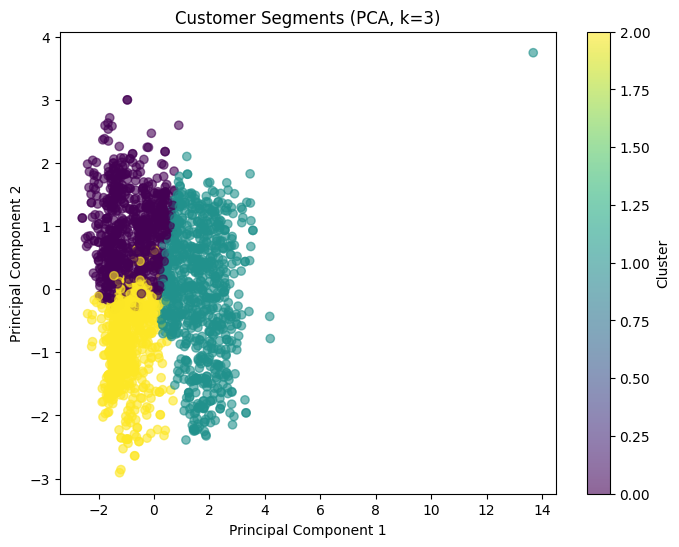

Explained variance ratio: [0.49994176 0.26983776]


In [339]:
pca = PCA(n_components=2, random_state=42)
cluster_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(cluster_pca[:, 0], cluster_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments (PCA, k={})'.format(k))
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_)

### Cluster Profiling

Compute mean values of `Income`, `TotalSpending`, `Age`, `TotalChildren` for each cluster and describe each segment.

In [340]:
cluster_profile = df.groupby('Cluster')[cluster_features].mean().round(2)
print(cluster_profile.to_string())

print('\n--- Segment Descriptions ---')
for cluster_id in sorted(df['Cluster'].unique()):
    row = cluster_profile.loc[cluster_id]
    income_level = 'High' if row['Income'] > 55000 else ('Medium' if row['Income'] > 45000 else 'Low')
    spending_level = 'high' if row['TotalSpending'] > 400 else ('medium' if row['TotalSpending'] > 150 else 'low')
    age_level = 'young' if row['Age'] < 45 else ('middle-aged' if row['Age'] < 60 else 'senior')
    children_level = 'with children' if row['TotalChildren'] > 0.5 else 'without children'
    print(f'  Cluster {cluster_id}: {income_level}-income, {spending_level} spending, {age_level}, {children_level}')

         TotalSpending    Income    Age  TotalChildren
Cluster                                               
0               298.55  47278.93  63.94           1.69
1              1289.28  74150.17  58.64           0.39
2               159.80  33161.61  48.77           0.84

--- Segment Descriptions ---
  Cluster 0: Medium-income, medium spending, senior, with children
  Cluster 1: High-income, high spending, middle-aged, without children
  Cluster 2: Low-income, medium spending, middle-aged, with children
